# Task: Correcation

**Student Name:**  Sandra Senn

**Country:**  Morocco

**Semester term:** FS26  

**Repository:** https://github.com/Sandra-Senn/gbsv_mc

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import wavfile as wav
from scipy import signal
import IPython.display as ipd
from moviepy import VideoFileClip

In [11]:
def load_audio(path='../mc1/data/dromedar.wav'):
    """Load, mono-convert and normalize a WAV file.
    Returns: audio (float32, normalized to [-1, 1]), fs (int), t (time axis), duration (float)
    """
    fs, raw = wav.read(path)
    if raw.ndim == 2:
        raw = raw.mean(axis=1).astype(raw.dtype)
    audio = raw.astype(np.float32) / np.iinfo(raw.dtype).max
    t = np.arange(len(audio)) / fs
    duration = len(audio) / fs
    return audio, fs, t, duration

def band_rms(audio, fs, f_low, f_high, frame, hop):
    """Compute RMS envelope of a bandpass-filtered signal."""
    sos = signal.butter(4, [f_low, f_high], btype='band', fs=fs, output='sos')
    filtered = signal.sosfilt(sos, audio)
    return np.array([np.sqrt(np.mean(filtered[i:i+frame]**2))
                     for i in range(0, len(filtered) - frame, hop)])


## Morocco - Dromedar Market

<p style="display: flex; align-items: center;">
  <img src="data/img/spices.jpeg" style="width:300px; margin-right:20px;">
  <span style="flex: 1;">
  Still echoing in my memory from that chaotic, colorful Wednesday market in Guelmim — the piercing cry of a baby dromedary cuts through the crowd noise like a needle through fabric. I had my phone out, filming. What I didn't know then was that this 2.4-second recording would become the backbone of this entire Mini Challenge.
  Now, in Week 2, I return to the same signal — not to ask <em>how fast to sample it</em>, but to ask a different question: <strong>can we find the rhythm hidden inside the cry, and can we locate it within the noise?</strong>
  </span>
</p>

## Day 6 – Data & Domain

### Use Case

In the context of acoustic welfare monitoring at Swiss Zoons, dromedary vocalizations are generated by the animal's laryngeal and vocal-tract anatomy under stress or excitation and recorded using a smartphone camera microphone in order to extract structured acoustic events from ambient field recordings.

These signals are used by veterinarians and zoo staff to perform non-invasive stress-state classification based on the pitch periodicity and timbral features of the cry.

This use case is particularly relevant for Switzerland because institutions such as Zoo Basel prioritize ethical, low-cost acoustic monitoring of exotic species, directly linking field recordings from Morocco to local conservation and animal welfare practice.

### Problem Statement
*Focus: technical vulnerability*

This project addresses the problem of applying correlation-based analysis to a single 2.4 s field recording of a baby dromedary cry embedded in broadband market noise — including human voices, crowd chatter, and wind — within the context of acoustic welfare monitoring at Zoo Basel, Switzerland.

If correlation methods are applied to the full, unfiltered signal, the presence of other voiced sources (human speech, f₀ ≈ 85–255 Hz) may produce competing periodic peaks, leading to ambiguous or incorrect periodicity detection and unreliable segment localization.


Preserving the structural integrity of the dromedary cry segment is essential for reliable stress-state assessment in this non-invasive monitoring use case — requiring that the cry is first **localized** via cross-correlation before its **internal structure** is analyzed via auto-correlation.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

This investigation follows a **two-step approach** that directly addresses the ambiguity introduced by mixed voiced sources in the recording:

**Step 1 – Cross-correlation:** Localize the dromedary cry segment within the full 2.4 s ambient recording by correlating the full signal against a known template extracted from the peak-energy region. This isolates the cry from the surrounding market noise and human voices.

**Step 2 – Auto-correlation:** Analyze the internal periodic structure of the isolated cry segment to characterize its quasi-periodic glottal pulse pattern. This step is only meaningful on the isolated segment — applying it to the full signal would conflate the dromedary's periodicity with that of human speech in the background.

Together, these two steps provide a methodologically sound and domain-relevant analysis pipeline for automated cry detection and structure characterization in zoo welfare monitoring.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

The selected signal is the same **baby dromedary vocalization** (field recording, Guelmim camel market, Morocco, February 2026) used in the Sampling Theorem task — a mono WAV file sampled at **44 100 Hz**, **2.415 s** in duration, normalized to amplitude ∈ [−1, +1]. The recording contains a single, concentrated cry burst with peak acoustic activity at **t ≈ 1.59 s**, embedded in continuous broadband market noise including human voices, crowd chatter, and wind. The cry exhibits a quasi-periodic glottal pulse structure with a fundamental frequency of **f₀ ≈ 428 Hz**, while the background human voices occupy a lower frequency range (f₀ ≈ 85–255 Hz) — a spectral separation that motivates the two-step analysis approach. A **300 ms template** centred on the peak-energy region (t ≈ 1.49–1.79 s) is extracted as the reference segment for cross-correlation-based localization. The data originate from a personal field recording and are appropriate because they represent a realistic, unprocessed acoustic scenario that directly motivates the methodological challenges addressed in this analysis.

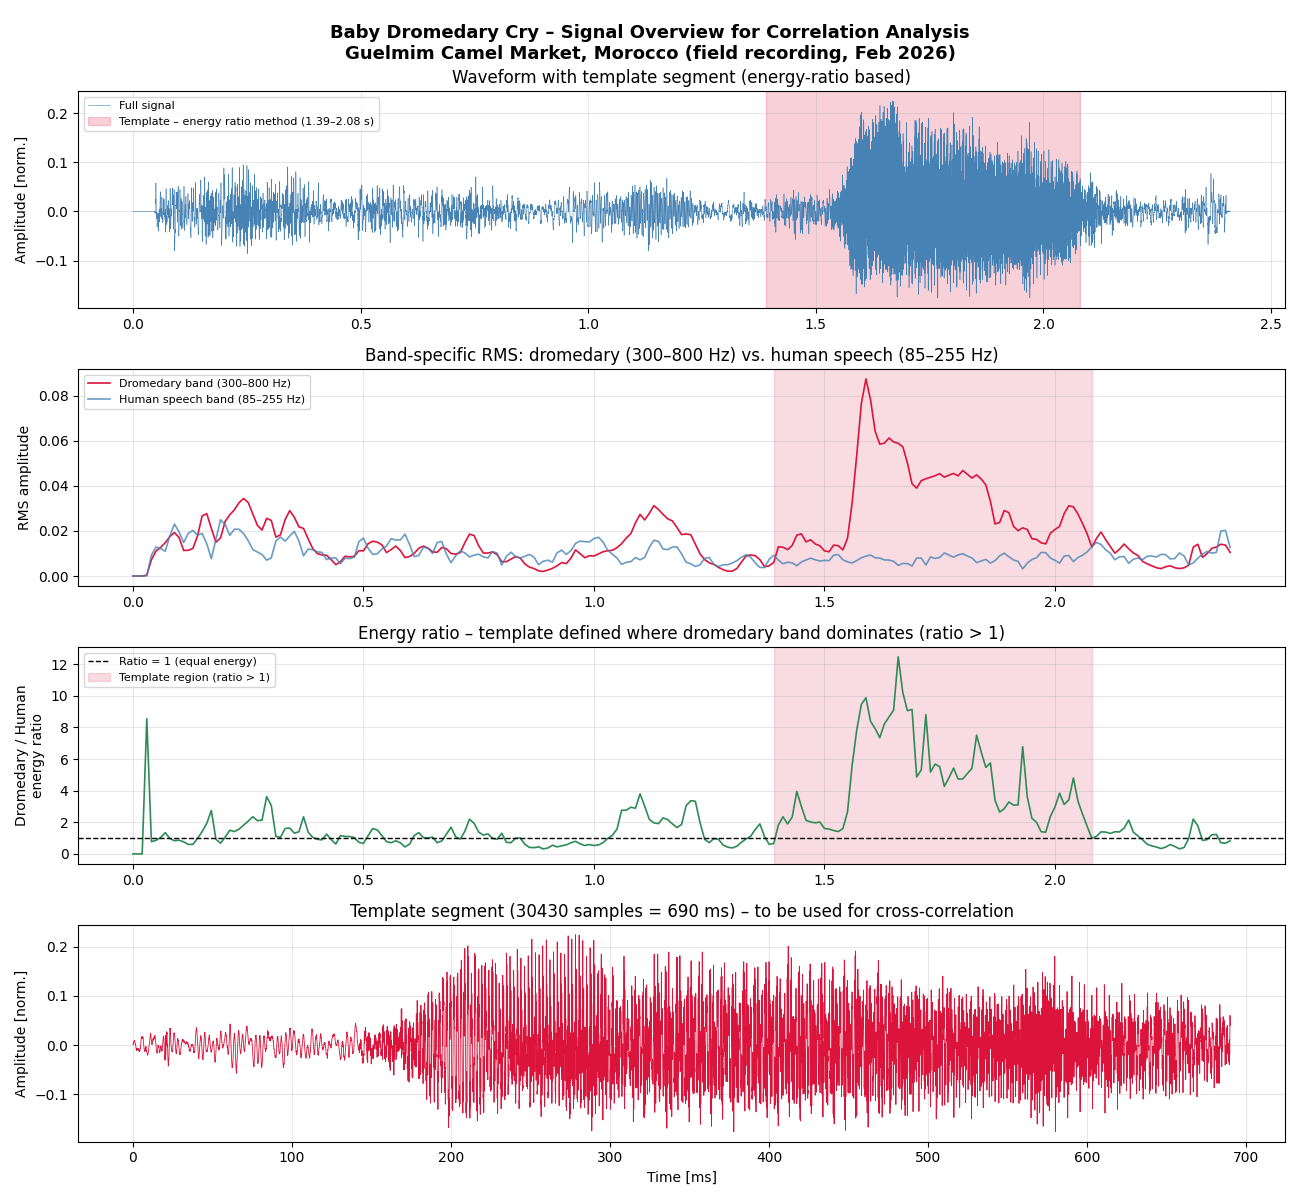

Signal length    : 106281 samples (2.410 s) @ 44100 Hz
Template start   : 1.390 s  (61298 samples)
Template end     : 2.080 s  (91728 samples)
Template length  : 30430 samples (690 ms)
Template method  : energy ratio (dromedary band / human band > 1)

Original recording:


In [12]:
audio, fs, t, duration = load_audio()


#  RMS envelope parameters 
frame = int(0.02 * fs)   # 20 ms frames
hop   = frame // 2
t_rms = np.arange(len(band_rms(audio, fs, 300, 800, frame, hop))) * hop / fs

rms_dromedar = band_rms(audio, fs, 300, 800, frame, hop)  # dromedary f0 range
rms_human    = band_rms(audio, fs, 85,  255, frame, hop)  # human speech range

#  Template: contiguous region around peak where dromedary band dominates 
# Ratio > 1 means dromedary band energy exceeds human speech band energy
ratio       = rms_dromedar / (rms_human + 1e-6)
ratio_above = ratio > 1.0
peak_idx    = np.argmax(rms_dromedar)

left = peak_idx
while left > 0 and ratio_above[left]:
    left -= 1
right = peak_idx
while right < len(ratio_above) - 1 and ratio_above[right]:
    right += 1

t_start  = t_rms[left]
t_end    = t_rms[right]
idx_s    = int(t_start * fs)
idx_e    = int(t_end   * fs)
template = audio[idx_s:idx_e]
t_tmpl   = np.arange(len(template)) / fs

#  Visualization 
fig, axes = plt.subplots(4, 1, figsize=(13, 12))
fig.suptitle('Baby Dromedary Cry – Signal Overview for Correlation Analysis\n'
             'Guelmim Camel Market, Morocco (field recording, Feb 2026)',
             fontsize=13, fontweight='bold')

# Waveform + template region
axes[0].plot(t, audio, color='steelblue', linewidth=0.4, label='Full signal')
axes[0].axvspan(t_start, t_end, color='crimson', alpha=0.2,
                label=f'Template – energy ratio method ({t_start:.2f}–{t_end:.2f} s)')
axes[0].set_ylabel('Amplitude [norm.]')
axes[0].set_title('Waveform with template segment (energy-ratio based)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Band-specific RMS
axes[1].plot(t_rms, rms_dromedar, color='crimson',   linewidth=1.2,
             label='Dromedary band (300–800 Hz)')
axes[1].plot(t_rms, rms_human,    color='steelblue', linewidth=1.2, alpha=0.8,
             label='Human speech band (85–255 Hz)')
axes[1].axvspan(t_start, t_end, color='crimson', alpha=0.15)
axes[1].set_ylabel('RMS amplitude')
axes[1].set_title('Band-specific RMS: dromedary (300–800 Hz) vs. human speech (85–255 Hz)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Energy ratio
axes[2].plot(t_rms, ratio, color='seagreen', linewidth=1.2)
axes[2].axhline(y=1.0, color='black', linestyle='--', linewidth=1,
                label='Ratio = 1 (equal energy)')
axes[2].axvspan(t_start, t_end, color='crimson', alpha=0.15,
                label='Template region (ratio > 1)')
axes[2].set_ylabel('Dromedary / Human\nenergy ratio')
axes[2].set_title('Energy ratio – template defined where dromedary band dominates (ratio > 1)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# Template zoom
axes[3].plot(t_tmpl * 1000, template, color='crimson', linewidth=0.6)
axes[3].set_xlabel('Time [ms]')
axes[3].set_ylabel('Amplitude [norm.]')
axes[3].set_title(f'Template segment ({len(template)} samples = '
                  f'{len(template)/fs*1000:.0f} ms) – to be used for cross-correlation')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Signal length    : {len(audio)} samples ({len(audio)/fs:.3f} s) @ {fs} Hz')
print(f'Template start   : {t_start:.3f} s  ({idx_s} samples)')
print(f'Template end     : {t_end:.3f} s  ({idx_e} samples)')
print(f'Template length  : {len(template)} samples ({len(template)/fs*1000:.0f} ms)')
print(f'Template method  : energy ratio (dromedary band / human band > 1)')

print('\nOriginal recording:')
ipd.display(ipd.Audio(audio, rate=fs))

# Initial approach: template defined as ±150 ms around the RMS peak (300 ms fixed window).
# This was rejected because the full-band RMS peak only captures the loudest moment,
# not the full extent of the cry. More critically, the full-band RMS cannot distinguish
# the dromedary vocalization from human voices in the background — both contribute
# broadband energy. The energy-ratio method (dromedary band 300–800 Hz vs. human speech
# band 85–255 Hz) addresses both issues: it captures the entire region where the dromedary
# spectrally dominates, yielding a physically motivated template of 690 ms instead of 300 ms.


**Observations**:

The visualization illustrates the full waveform, band-specific RMS envelopes, and energy ratio of the dromedary field recording, with a notable burst of dromedary-band energy (300–800 Hz) dominating over the human speech band (85–255 Hz) between **1.39 s and 2.08 s** — reaching a peak energy ratio of ~12 at t ≈ 1.59 s.

This region was selected as the cross-correlation template because it clearly highlights the spectral dominance of the dromedary vocalization over background human voices, directly relevant to the defined use case of acoustic welfare monitoring and the investigation objective of reliable cry localization in noisy field recordings.

## Day 7 – Methodological Design

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*


This investigation applies **cross-correlation** and **auto-correlation** as complementary tools within a two-step analysis pipeline for the dromedary welfare monitoring use case. Cross-correlation measures the similarity between a known template signal and a sliding window over the full recording — its peak position directly identifies where in time the dromedary cry occurs, making it appropriate for **segment localization**. Auto-correlation computes the self-similarity of a signal at varying lags — periodic signals produce regularly spaced peaks whose spacing equals the period, making it appropriate for **pitch-period detection** on the isolated cry segment. Both methods assume stationarity within the analysis window. This assumption is satisfied for cross-correlation (the template captures the full cry) but only approximately for auto-correlation (pitch varies slightly over 690 ms), which is acknowledged as a limitation.


### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

**Cross-correlation parameters:**

| Parameter | Value | Unit | Justification |
|:---|:---|:---|:---|
| Template start | 1.390 | s | Energy-ratio boundary (dromedary band dominates) |
| Template end | 2.080 | s | Energy-ratio boundary |
| Template length | 690 | ms (30 430 samples) | Full cry extent per spectral criterion |
| Normalization | L2-norm | — | Makes peak value amplitude-invariant |
| Mode | `valid` | — | Avoids boundary artifacts; output length = N − M + 1 |

**Auto-correlation parameters:**

| Parameter | Value | Unit | Justification |
|:---|:---|:---|:---|
| Input signal | Isolated template (690 ms) | — | Avoids human voice contamination |
| Max lag range | 500 | ms | Covers pitch periods down to 2 Hz; well above expected f₀ |
| Normalization | AC[0] = 1 | — | Standard biased estimator; enables peak height comparison |
| Peak detection threshold | 0.05 | — | Suppresses noise-induced false peaks |
| Min peak distance | 5 | ms (220 samples) | Below expected pitch period of ~2.3 ms |

The template length of 690 ms is derived from the energy-ratio criterion (Day 6) and corresponds to **30 430 samples** at 44 100 Hz. The expected dominant pitch period is **~2.27 ms** (f₀ ≈ 441 Hz), consistent with the fundamental frequency identified in the Sampling Theorem task (428 Hz), confirming that the auto-correlation lag axis should resolve sub-millisecond periodicities.


### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*


The **baseline configuration** is defined as a normalized cross-correlation in `valid` mode with the 690 ms energy-ratio template, and normalized auto-correlation with a 500 ms lag range on the isolated template.

The following parameters will be systematically varied:

|Method | Parameter | Values | Prediction |
|:---|:---|:---|:---|
| Cross-corr | Additive noise (SNR) | 20, 10, 5, 0 dB | Peak value decreases; localization stable until 0 dB |
| Cross-corr | Amplitude scaling | 0.1×, 0.5×, 1×, 2× | Peak value unchanged (L2-norm); localization unaffected |
| Auto-corr | Max lag range | 50, 100, 200, 500 ms | First peak stable; longer range reveals secondary structure |
| Auto-corr | Peak threshold | 0.02, 0.05, 0.10 | Lower threshold detects more peaks including noise peaks |

It is theoretically expected that normalized cross-correlation is fully robust to amplitude scaling (L2-normalization cancels constant amplitude factors) but will degrade gracefully under additive noise as the template becomes less similar to the target region. Auto-correlation peak spacing should remain stable across all lag ranges since the pitch period is a physical property of the signal, not of the analysis window.


### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

The cross-correlation approach assumes that the template faithfully represents the target segment in the full signal — since the template *is* extracted from the signal itself, a perfect match is guaranteed for the clean case, which may overstate robustness in real zoo deployments where the template would come from a separate reference recording. 

The auto-correlation assumes stationarity of the cry within the 690 ms window, which is only approximately satisfied as pitch and amplitude vary slightly over the cry duration — this may broaden the autocorrelation peaks and reduce pitch estimate precision. The energy-ratio template boundary (ratio > 1) depends on the specific noise conditions of this recording. In a quieter zoo environment the human speech band energy would be lower, potentially expanding the template region beyond the true cry extent.

## Day 8 – Implementation

*Focus: structured, traceable execution*

<span style="background-color: #eeeeee;">*Guidelines: Implement the previously defined methodological framework in a structured and reproducible manner. Organize your notebook clearly, separating data preparation, parameter definition, baseline configuration, and parameter variation. The implementation must directly follow the previously defined methodological plan. All relevant parameters must be explicitly declared and applied as specified. Do not introduce new methods or undocumented parameter changes; any deviation must be briefly justified (one sentence).
Ensure that each experiment is traceable by clearly labeling configurations and avoiding undocumented changes. Visualizations must include properly labeled axes (with units where applicable), clear legends, and consistent formatting to allow comparison across parameter settings.
 If not otherwise stated, libarys may be used for your implementations. Keep experiments concise and focused. Observations, interpretation and performance evaluation will be conducted on a later day.*</span>

<span style="background-color: #eeeeee;">*Code Quality Requirements: The submission must not contain any commented-out code passages. Code should be clean, readable, and executable without residual development artifacts. Comments should be used sparingly and only where they add value. In particular, comments are appropriate when explaining why a specific methodological decision was made, clarifying non-obvious implementation details, or referencing a theoretical source. Avoid redundant comments that merely restate what the code already expresses.
The code should be written in a clear and structured manner such that its logic is largely self-explanatory. Use meaningful variable names and consistent formatting to enhance readability.*</span>

## Day 9 – Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

<span style="background-color: #eeeeee;">*Systematically evaluate the predefined experiment design in relation to the defined use case. The evaluation must be traceable, structured, and based on consistent criteria. All reported metrics or extracted quantities must include appropriate physical units or clearly indicate normalization to ensure consistent and meaningful comparison. The same predefined evaluation approach must be applied consistently across all experiments and parameter configurations to maintain traceability and comparability.No new simulations, theoretical derivations, or interpretative discussion should be introduced.*</span>

### Evaluation Approach Definition

<span style="background-color: #eeeeee;">*Guidelines: Define 1–2 quantitative evaluation approaches, which may consist of numerical metrics and/or quantitatively interpretable visualizations. Justify why the selected approach is appropriate for your signal or image characteristics and application objective, and clearly specify what aspect of performance it captures (e.g., fidelity, detection accuracy, reconstruction quality, robustness, distortion). Visualizations must include labeled axes with units and enable measurable comparison across configurations. 2-3 sentences.*</span>

You may use the following structures as guidance, depending on whether your evaluation approach is metric-based or visualization-based.

#### Template – Metric-Based Evaluation

> The selected metric is __________, which quantifies ____________ in relation to [the defined use case].
It is specifically chosen because the problem statement requires accurate assessment of ____________, and this metric directly reflects changes in ____________.
The validity of this metric depends on ____________, which must hold for the evaluation to be meaningful in this application.

Example – Root Mean Squared Error (RMSE):

> The selected metric is RMSE, which quantifies the deviation between the reconstructed signal and the high-resolution reference. It is specifically chosen because [the use case] requires accurate amplitude reconstruction over time, and RMSE directly reflects reconstruction fidelity. The metric is meaningful here because a validated reference signal is available and serves as ground truth.

#### Template – Visualization-Based Evaluation

> The evaluation uses a __________ visualization, representing ____________ with clearly labeled axes and units.
The evaluated quantity is ____________, which is directly relevant to [the defined use case] because the problem requires reliable assessment of ____________.
This approach is appropriate under ____________, ensuring that the extracted feature meaningfully reflects performance in this application context.

Example – Frequency Spectrum Comparison:

> The evaluation uses a frequency spectrum visualization to assess whether dominant periodic components are preserved. The evaluated quantity is the measurable peak frequency and its amplitude, which are directly relevant because the use case requires reliable detection of periodic behavior. This approach is appropriate since frequency preservation is more critical than pointwise amplitude accuracy in this application.

### Evaluation Comparison Execution

<span style="background-color: #eeeeee;">*Guidelines: Apply the defined evaluation approach consistently across all predefined experiments or configurations. Systematically vary 2–4 previously defined key parameters and quantify their influence on performance relative to a clearly specified baseline configuration. Results must be reported in a structured format (e.g., tables or measurable graphics) to ensure traceability. 2-4 sentences.*</span>


#### Template – Parameter Evaluation (Metric-Based)

>The influence of key parameters __________ was evaluated using the previously defined metric __________.
These parameters are essential for [the defined use case] because they directly affect ____________, which is critical for ____________.
Changes in __________ [metric] across parameter settings quantify how sensitive the experiment design is to ____________.
Relative performance change was computed with respect to the baseline configuration ____________.

#### Template – Parameter Evaluation (Visualization-Based)

>The influence of key parameters __________ was evaluated using the previously defined visualization-based measure __________.
These parameters are essential for the defined use case because they influence ____________, which determines ____________ in [the application context].
Differences in the extracted quantity __________ across parameter settings quantify the impact of ____________ on performance.
Relative performance change was computed with respect to the baseline configuration ____________.

In [13]:
## Placeholder for code-based analysis, quantitative result reporting, and structured comparison using tables and/or graphics.

Example universal comparison table:

| Experiment / Configuration        | Metric / Quantity 1 | Metric / Quantity 2 (optional) | Relative Change to Baseline (%) |
|:----------------------------------|:--------------------|:--------------------------------|:--------------------------------|
| Baseline: ____________            |                     |                                  | 0%                               |
| Configuration 1: ____________     |                     |                                  |                                  |
| Configuration 2: ____________     |                     |                                  |                                  |
| Configuration 3: ____________     |                     |                                  |                                  |


Example for Sampling Rate Variation:


| Experiment / Configuration | RMSE | Relative Change to Baseline (%) |
|:----------------------------|:-----|:--------------------------------|
| Baseline: Fs = 100 Hz      | 0.12 | 0%                               |
| Fs = 50 Hz                 | 0.18 | +50%                             |
| Fs = 25 Hz                 | 0.45 | +275%                            |

## Day 10 – Analysis & Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image. Structure your analysis into (1) observations, (2) interpretation, and (3) discussion. Observations must reference concrete quantitative results; interpretations must explain domain-specific implications; the discussion must critically assess the practical applicability, limitations, and risks of your implementation and evaluation approach. All arguments must explicitly connect to the original problem statement and use case. No new simulations or derivations may be introduced.*</span>

### Observations (3-5 sentences)
Focus: Describe measurable results only — no explanation.

> The quantitative evaluation shows that ____________ changes from ____________ to ____________ across configurations ____________.
The defined metric / extracted quantity indicates that ____________.
Performance differences are most pronounced when ____________.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.

>In the context of ____________ [use case], these results imply that ____________.
The observed variation in ____________ affects ____________ because ____________.
This suggests that ____________ is particularly critical for achieving the objective defined in the problem statement.


### Discussion and Critical Reflection (4–6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*

> For the defined use case, the configurations ____________ performed well because they achieved ____________, which aligns with the requirement of ____________.
In contrast, configurations ____________ showed reduced performance, leading to ____________ and limiting their suitability for this application.
The achieved performance level can be considered sufficient / insufficient for the use case because ____________.
The implementation and evaluation approach assumes ____________, which may be constrained under real-world conditions such as ____________.
To improve robustness or applicability, future work should address ____________ or refine ____________.